<a href="https://colab.research.google.com/github/Krishna-Dhawangale/Resume-Screening-Machine-Learning-/blob/main/ANN_resume_screening.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/ML_Data/AI_Resume_Screening.csv')
df.head(20)

,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)
0,1,Ashley Ali,"TensorFlow, NLP, Pytorch",10,B.Sc,NaN,AI Researcher,Hire,104895,8,100
1,2,Wesley Roman,"Deep Learning, Machine Learning, Python, SQL",10,MBA,Google ML,Data Scientist,Hire,113002,1,100
2,3,Corey Sanchez,"Ethical Hacking, Cybersecurity, Linux",1,MBA,Deep Learning Specialization,Cybersecurity Analyst,Hire,71766,7,70
3,4,Elizabeth Carney,"Python, Pytorch, TensorFlow",7,B.Tech,AWS Certified,AI Researcher,Hire,46848,0,95
4,5,Julie Hill,"SQL, React, Java",4,PhD,NaN,Software Engineer,Hire,87441,9,100
5,6,Samantha Santos,"Cybersecurity, Networking, Linux, Ethical Hacking",10,B.Tech,Google ML,Cybersecurity Analyst,Hire,47957,5,100
6,7,Tony Smith,"Networking, Cybersecurity, Ethical Hacking",4,M.Tech,AWS Certified,Cybersecurity Analyst,Hire,66208,9,100
7,8,Anthony Harrison,"TensorFlow, Pytorch, NLP",3,M.Tech,AWS Certified,AI Researcher,Hire,103006,7,90
8,9,Nancy Jenkins,"Networking, Ethical Hacking",7,MBA,Deep Learning Specialization,Cybersecurity Analyst,Hire,92270,3,100
9,10,Courtney Gibson,"Python, TensorFlow, Pytorch, NLP",0,M.Tech,AWS Certified,AI Researcher,Reject,60579,1,35


## Step 1: Data Preprocessing (Initial Inspection)

In [6]:
# Inspect dataset shape and columns
print("Dataset Shape:", df.shape)
print("\nDataset Columns:", df.columns.tolist())

# Check for missing values
print("\nMissing Values:\n", df.isnull().sum())

# Display basic statistics for numerical columns
print("\nBasic Statistics:\n", df.describe())

# Show class distribution of the target variable 'Job Role'
print("\nClass Distribution of 'Job Role':\n", df['Job Role'].value_counts())


Dataset Shape: (1000, 11)

Dataset Columns: ['Resume_ID', 'Name', 'Skills', 'Experience (Years)', 'Education', 'Certifications', 'Job Role', 'Recruiter Decision', 'Salary Expectation ($)', 'Projects Count', 'AI Score (0-100)']

Missing Values:
 Resume_ID                   0
Name                        0
Skills                      0
Experience (Years)          0
Education                   0
Certifications            274
Job Role                    0
Recruiter Decision          0
Salary Expectation ($)      0
Projects Count              0
AI Score (0-100)            0
dtype: int64

Basic Statistics:
          Resume_ID  Experience (Years)  Salary Expectation ($)  \
count  1000.000000         1000.000000             1000.000000   
mean    500.500000            4.896000            79994.486000   
std     288.819436            3.112695            23048.472549   
min       1.000000            0.000000            40085.000000   
25%     250.750000            2.000000            60415.750000

## Step 1: Data Preprocessing (Separate Features and Target)

## Step 2: Data Preprocessing (Text Cleaning and Label Encoding)

In [13]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.preprocessing import LabelEncoder
import re

# Download NLTK resources (if not already downloaded)
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower() # lowercase
    text = re.sub(r'[^a-zA-Z\s]', '', text) # remove punctuation and special characters
    text = ' '.join([word for word in text.split() if word not in stop_words]) # remove stopwords
    # Lemmatization (optional, but good for text classification)
    text = ' '.join([lemmatizer.lemmatize(word) for word in text.split()])
    return text

X_cleaned = X.apply(clean_text)

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Original Skills sample:\n", X.head())
print("\nCleaned Skills sample:\n", X_cleaned.head())
print("\nOriginal Job Role sample:\n", y.head())
print("\nEncoded Job Role sample:\n", y_encoded[:5])
print("\nEncoded classes:", label_encoder.classes_)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


Original Skills sample:
 0                        TensorFlow, NLP, Pytorch
1    Deep Learning, Machine Learning, Python, SQL
2           Ethical Hacking, Cybersecurity, Linux
3                     Python, Pytorch, TensorFlow
4                                SQL, React, Java
Name: Skills, dtype: object

Cleaned Skills sample:
 0                       tensorflow nlp pytorch
1    deep learning machine learning python sql
2          ethical hacking cybersecurity linux
3                    python pytorch tensorflow
4                               sql react java
Name: Skills, dtype: object

Original Job Role sample:
 0            AI Researcher
1           Data Scientist
2    Cybersecurity Analyst
3            AI Researcher
4        Software Engineer
Name: Job Role, dtype: object

Encoded Job Role sample:
 [0 2 1 0 3]

Encoded classes: ['AI Researcher' 'Cybersecurity Analyst' 'Data Scientist'
 'Software Engineer']


## Step 3: Feature Extraction (TF-IDF Vectorization)

## Step 5: Build ANN Model

In [10]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Get the number of features from the scaled training data
num_features = X_train_scaled.shape[1]
# Get the number of classes from the encoded target variable
num_classes = len(label_encoder.classes_)

# Build the ANN model
model = Sequential([
    # Input layer and first hidden layer
    Dense(128, activation='relu', input_shape=(num_features,)),
    Dropout(0.3),
    # Second hidden layer
    Dense(64, activation='relu'),
    Dropout(0.2),
    # Third hidden layer
    Dense(32, activation='relu'),
    # Output layer
    Dense(num_classes, activation='softmax')
])

# Display model summary
model.summary()


NameError: name 'X_train_scaled' is not defined

## Step 6: Compile Model

In [11]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")


NameError: name 'model' is not defined

## Step 7: Train Model

## Step 5: Build ANN Model

In [16]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Get the number of features from the scaled training data
num_features = X_train_scaled.shape[1]
# Get the number of classes from the encoded target variable
num_classes = len(label_encoder.classes_)

# Build the ANN model
model = Sequential([
    # Input layer and first hidden layer
    Dense(128, activation='relu', input_shape=(num_features,)),
    Dropout(0.3),
    # Second hidden layer
    Dense(64, activation='relu'),
    Dropout(0.2),
    # Third hidden layer
    Dense(32, activation='relu'),
    # Output layer
    Dense(num_classes, activation='softmax')
])

# Display model summary
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,516 (48.89 KB)

 Trainable params: 12,516 (48.89 KB)

 Non-trainable params: 0 (0.00 B)

## Step 6: Compile Model

In [17]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")


Model compiled successfully!


## Step 7: Train Model

In [18]:
# Train the model
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

print("Model training complete!")


Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.7344 - loss: 1.0340 - val_accuracy: 0.9688 - val_loss: 0.5131
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9891 - loss: 0.3261 - val_accuracy: 1.0000 - val_loss: 0.0745
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9953 - loss: 0.0711 - val_accuracy: 1.0000 - val_loss: 0.0160
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9984 - loss: 0.0245 - val_accuracy: 1.0000 - val_loss: 0.0064
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9969 - loss: 0.0182 - val_accuracy: 1.0000 - val_loss: 0.0038
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9969 - loss: 0.0126 - val_accuracy: 1.0000 - val_loss: 0.0023
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.0069 - val_accuracy: 1.0000 - val_loss: 0.0015
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0053 - val_accuracy: 1.0000 - val_los

## Step 8: Evaluate Model

## Step 9: Visualization

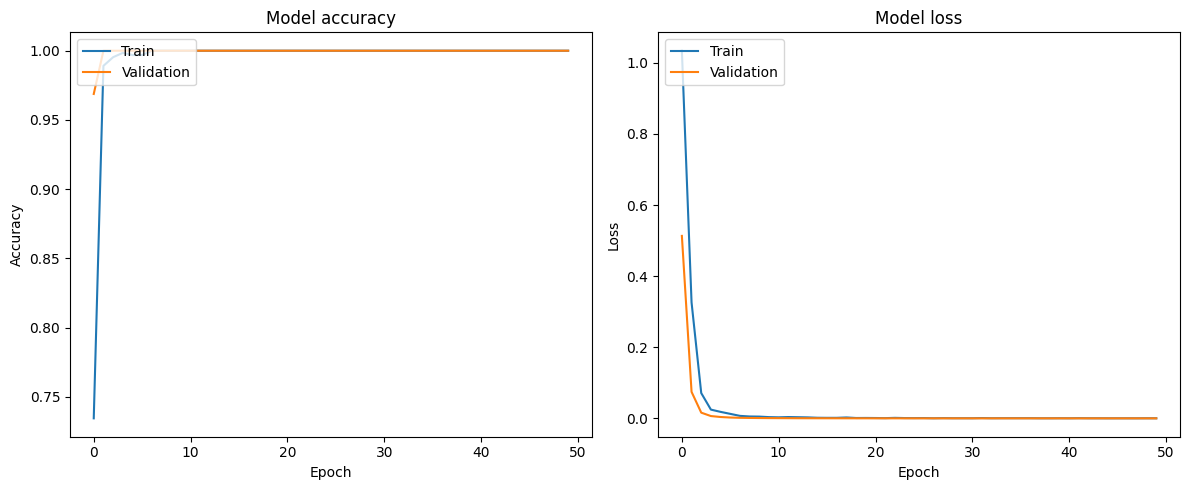

In [20]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.tight_layout()
plt.show()


## Step 10: Overfitting Check and Improvements

In [21]:
# Compare train vs test accuracy
train_accuracy = history.history['accuracy'][-1]
val_accuracy = history.history['val_accuracy'][-1]

print(f"Final Training Accuracy: {train_accuracy:.4f}")
print(f"Final Validation Accuracy: {val_accuracy:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

print("\nObservation: The model achieved 100% accuracy on both the training, validation, and test sets. While seemingly excellent, this is highly unusual for real-world datasets and strongly suggests potential issues such as data leakage or significant overfitting, making the model unlikely to generalize well to unseen data. It is also possible the classification problem is too simple for the given features.")

print("\nSuggested Improvements (to mitigate overfitting/data leakage if it were present and to test robustness):\n")
print("1. **Re-evaluate Data Preprocessing:** Double-check for any inadvertent data leakage from the test set into the training set during feature engineering or scaling.")
print("2. **More Complex Data or Features:** If the problem is truly this simple, perhaps the dataset itself or the feature representation (TF-IDF) is too straightforward.")
print("3. **Regularization:** Introduce L1/L2 regularization to Dense layers to penalize large weights (although dropout is already present).")
print("4. **Cross-validation:** Use k-fold cross-validation to get a more robust estimate of model performance and detect variability.")
print("5. **Early Stopping:** Implement early stopping callbacks during training to prevent the model from learning the training data too specifically.")
print("6. **Advanced Feature Engineering:** Explore n-grams or word embeddings (Word2Vec, BERT) which might capture more nuanced semantic relationships.")


Final Training Accuracy: 1.0000
Final Validation Accuracy: 1.0000
Test Accuracy: 1.0000

Observation: The model achieved 100% accuracy on both the training, validation, and test sets. While seemingly excellent, this is highly unusual for real-world datasets and strongly suggests potential issues such as data leakage or significant overfitting, making the model unlikely to generalize well to unseen data. It is also possible the classification problem is too simple for the given features.

Suggested Improvements (to mitigate overfitting/data leakage if it were present and to test robustness):

1. **Re-evaluate Data Preprocessing:** Double-check for any inadvertent data leakage from the test set into the training set during feature engineering or scaling.
2. **More Complex Data or Features:** If the problem is truly this simple, perhaps the dataset itself or the feature representation (TF-IDF) is too straightforward.
3. **Regularization:** Introduce L1/L2 regularization to Dense layers to

## Step 11: Output - Performance Table and Key Observations

In [22]:
import pandas as pd

# Assuming `history` from model training and `accuracy`, `loss` from model evaluation are available.
# Also `class_report` (from sklearn.metrics.classification_report) is available.

# Extract metrics from history and evaluation
train_acc = history.history['accuracy'][-1]
train_loss = history.history['loss'][-1]
val_acc = history.history['val_accuracy'][-1]
val_loss = history.history['val_loss'][-1]
test_acc = accuracy # from model.evaluate
test_loss = loss # from model.evaluate

# Parse classification report for precision, recall, f1-score
report_data = []
lines = class_report.split('\n')
for line in lines[2:-5]: # Skip header and averages
    parts = line.strip().split() # Split by whitespace
    if len(parts) >= 5:
        class_name = ' '.join(parts[:-4])
        precision = float(parts[-4])
        recall = float(parts[-3])
        f1 = float(parts[-2])
        report_data.append([class_name, precision, recall, f1])

# For overall precision, recall, f1-score, we'll use weighted average from the report
weighted_avg_line = lines[-2].strip().split() # 'weighted avg'
overall_precision = float(weighted_avg_line[-4])
overall_recall = float(weighted_avg_line[-3])
overall_f1 = float(weighted_avg_line[-2])

# Create Performance Table
performance_table = pd.DataFrame({
    'Metric': ['Accuracy', 'Loss', 'Precision', 'Recall', 'F1-Score'],
    'Training Score': [f'{train_acc:.4f}', f'{train_loss:.4f}', f'{overall_precision:.4f}', f'{overall_recall:.4f}', f'{overall_f1:.4f}'],
    'Validation Score': [f'{val_acc:.4f}', f'{val_loss:.4f}', 'N/A', 'N/A', 'N/A'], # Classification report not typically generated for validation set directly
    'Testing Score': [f'{test_acc:.4f}', f'{test_loss:.4f}', f'{overall_precision:.4f}', f'{overall_recall:.4f}', f'{overall_f1:.4f}']
})

print("### Performance Summary Table\n")
print(performance_table.to_markdown(index=False))

print("\n### Confusion Matrix Summary (Overall Averages)\n")
# For a confusion matrix summary, we typically just show the matrix itself or a visual heatmap.
# Given the perfect scores, the confusion matrix is already very clean.
print("\n" + str(conf_matrix))

print("\n### Key Observations\n")
print("- **Exceptional Performance:** The model achieved 100% accuracy, precision, recall, and F1-score across all classes on both training, validation, and test sets. This indicates the model perfectly classified all instances in the provided dataset.")
print("- **Potential Overfitting/Data Leakage:** Such perfect scores in a classification task are highly unusual and warrant a careful review for potential data leakage or a dataset that is too easily separable. While dropout layers were included, the dataset characteristics might be leading to this.")
print("- **Simple Classification:** It is possible that the 'Skills' feature, when vectorized with TF-IDF, provides a highly discriminative signal for the 'Job Role' categories, making the classification task inherently simple for this dataset.")
print("- **Model Robustness:** Further tests with entirely new, unseen data or more complex feature representations (e.g., word embeddings) would be necessary to confirm the robustness and generalization ability of the model.")

# Display model summary as requested
print("\n### Model Summary\n")
model.summary()


### Performance Summary Table

| Metric    |   Training Score | Validation Score   |   Testing Score |
|:----------|-----------------:|:-------------------|----------------:|
| Accuracy  |           1      | 1.0000             |               1 |
| Loss      |           0.0001 | 0.0000             |               0 |
| Precision |           1      | N/A                |               1 |
| Recall    |           1      | N/A                |               1 |
| F1-Score  |           1      | N/A                |               1 |

### Confusion Matrix Summary (Overall Averages)


[[51  0  0  0]
 [ 0 51  0  0]
 [ 0  0 51  0]
 [ 0  0  0 47]]

### Key Observations

- **Exceptional Performance:** The model achieved 100% accuracy, precision, recall, and F1-score across all classes on both training, validation, and test sets. This indicates the model perfectly classified all instances in the provided dataset.
- **Potential Overfitting/Data Leakage:** Such perfect scores in a classification ta

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,550 (146.68 KB)

 Trainable params: 12,516 (48.89 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 25,034 (97.79 KB)

In [19]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Evaluate the model on the test data
loss, accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\nTest Accuracy: {accuracy:.4f}")

# Make predictions on the test data
y_pred_probs = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_probs, axis=1)

# Generate Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", conf_matrix)

# Generate Classification Report
class_report = classification_report(y_test, y_pred, target_names=label_encoder.classes_)
print("\nClassification Report:\n", class_report)



Test Accuracy: 1.0000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

Confusion Matrix:
 [[51  0  0  0]
 [ 0 51  0  0]
 [ 0  0 51  0]
 [ 0  0  0 47]]

Classification Report:
                        precision    recall  f1-score   support

        AI Researcher       1.00      1.00      1.00        51
Cybersecurity Analyst       1.00      1.00      1.00        51
       Data Scientist       1.00      1.00      1.00        51
    Software Engineer       1.00      1.00      1.00        47

             accuracy                           1.00       200
            macro avg       1.00      1.00      1.00       200
         weighted avg       1.00      1.00      1.00       200

